# ✈️ Flight Price Prediction
**Author:** Ditsu Kundu  
**Dataset:** Cleaned_dataset.csv (452,088 records, 13 features)  
**Goal:** Predict flight fare (INR) using machine learning.

---
## Table of Contents
1. [Import Libraries](#1)
2. [Load & Inspect Data](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Feature Engineering & Preprocessing](#4)
5. [Model Training](#5)
6. [Model Evaluation](#6)
7. [Feature Importance](#7)
8. [Save Model](#8)

## 1. Import Libraries <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


## 2. Load & Inspect Data <a id='2'></a>

In [2]:
df = pd.read_csv('Cleaned_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (452088, 13)


,Date_of_journey,Journey_day,Airline,Flight_code,Class,Source,Departure,Total_stops,Arrival,Destination,Duration_in_hours,Days_left,Fare
0,2023-01-16,Monday,SpiceJet,SG-8169,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5335
1,2023-01-16,Monday,Indigo,6E-2519,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.3333,1,5899
2,2023-01-16,Monday,GO FIRST,G8-354,Economy,Delhi,After 6 PM,non-stop,Before 6 AM,Mumbai,2.1667,1,5801
3,2023-01-16,Monday,SpiceJet,SG-8709,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.0833,1,5794
4,2023-01-16,Monday,Air India,AI-805,Economy,Delhi,After 6 PM,non-stop,After 6 PM,Mumbai,2.1667,1,5955


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 452088 entries, 0 to 452087
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Date_of_journey    452088 non-null  str    
 1   Journey_day        452088 non-null  str    
 2   Airline            452088 non-null  str    
 3   Flight_code        452088 non-null  str    
 4   Class              452088 non-null  str    
 5   Source             452088 non-null  str    
 6   Departure          452088 non-null  str    
 7   Total_stops        452088 non-null  str    
 8   Arrival            452088 non-null  str    
 9   Destination        452088 non-null  str    
 10  Duration_in_hours  452088 non-null  float64
 11  Days_left          452088 non-null  int64  
 12  Fare               452088 non-null  int64  
dtypes: float64(1), int64(2), str(10)
memory usage: 80.4 MB


In [4]:
df.describe(include='all')

,Date_of_journey,Journey_day,Airline,Flight_code,Class,Source,Departure,Total_stops,Arrival,Destination,Duration_in_hours,Days_left,Fare
count,452088,452088,452088,452088,452088,452088,452088,452088,452088,452088,452088.000000,452088.000000,452088.000000
unique,50,7,9,1405,4,7,4,3,4,7,NaN,NaN,NaN
top,2023-01-31,Monday,Vistara,UK-936,Economy,Delhi,6 AM - 12 PM,1-stop,After 6 PM,Mumbai,NaN,NaN,NaN
freq,9824,72220,231490,5506,252033,83153,184980,369650,200266,82995,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.349222,25.627902,22840.100890
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.431478,14.300846,20307.963002
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.750000,1.000000,1307.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.583300,13.000000,8762.750000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.333300,26.000000,13407.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.500000,38.000000,35587.000000


In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal duplicates: {df.duplicated().sum()}')

Missing values per column:
Date_of_journey      0
Journey_day          0
Airline              0
Flight_code          0
Class                0
Source               0
Departure            0
Total_stops          0
Arrival              0
Destination          0
Duration_in_hours    0
Days_left            0
Fare                 0
dtype: int64

Total duplicates: 6722


In [6]:
print('Unique values per categorical column:')
for col in ['Airline', 'Class', 'Source', 'Destination', 'Total_stops', 'Departure', 'Arrival', 'Journey_day']:
    print(f'  {col}: {df[col].unique()}')

Unique values per categorical column:
  Airline: <ArrowStringArray>
[   'SpiceJet',      'Indigo',    'GO FIRST',   'Air India',     'AirAsia',
     'Vistara',    'AkasaAir', 'AllianceAir',     'StarAir']
Length: 9, dtype: str
  Class: <ArrowStringArray>
['Economy', 'Premium Economy', 'Business', 'First']
Length: 4, dtype: str
  Source: <ArrowStringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Hyderabad', 'Kolkata', 'Chennai',
 'Ahmedabad']
Length: 7, dtype: str
  Destination: <ArrowStringArray>
['Mumbai', 'Bangalore', 'Hyderabad', 'Kolkata', 'Chennai', 'Ahmedabad',
 'Delhi']
Length: 7, dtype: str
  Total_stops: <ArrowStringArray>
['non-stop', '1-stop', '2+-stop']
Length: 3, dtype: str
  Departure: <ArrowStringArray>
['After 6 PM', 'Before 6 AM', '12 PM - 6 PM', '6 AM - 12 PM']
Length: 4, dtype: str
  Arrival: <ArrowStringArray>
['After 6 PM', 'Before 6 AM', '6 AM - 12 PM', '12 PM - 6 PM']
Length: 4, dtype: str
  Journey_day: <ArrowStringArray>
['Monday', 'Tuesday', 'Wednesday', 'Thursday',

## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

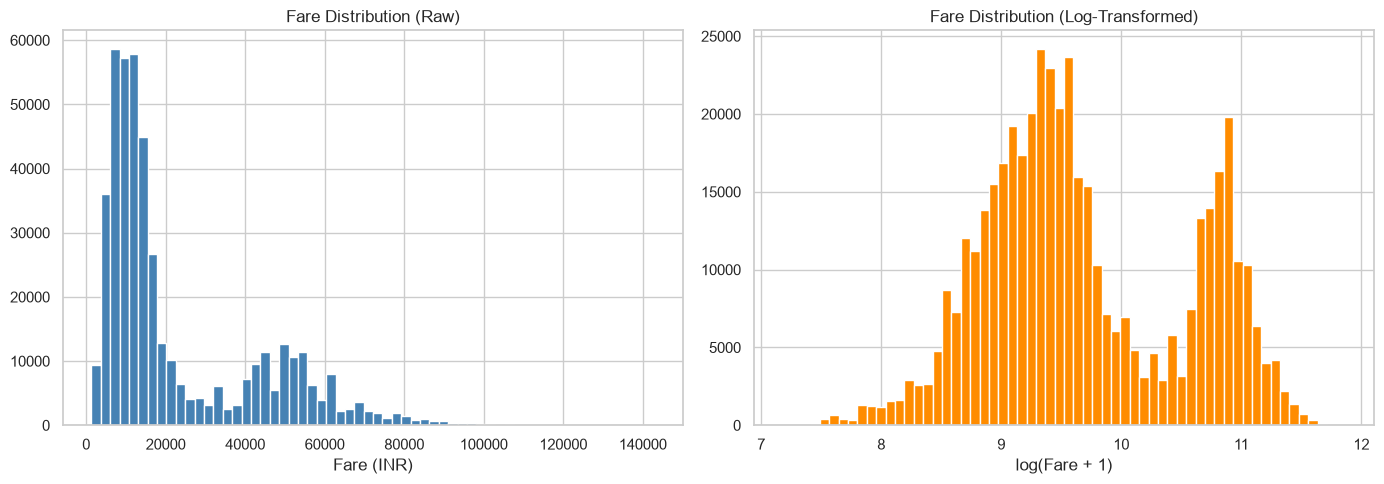

In [7]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Fare'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Fare Distribution (Raw)')
axes[0].set_xlabel('Fare (INR)')
axes[1].hist(np.log1p(df['Fare']), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Fare Distribution (Log-Transformed)')
axes[1].set_xlabel('log(Fare + 1)')
plt.tight_layout()
plt.savefig('plots/fare_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

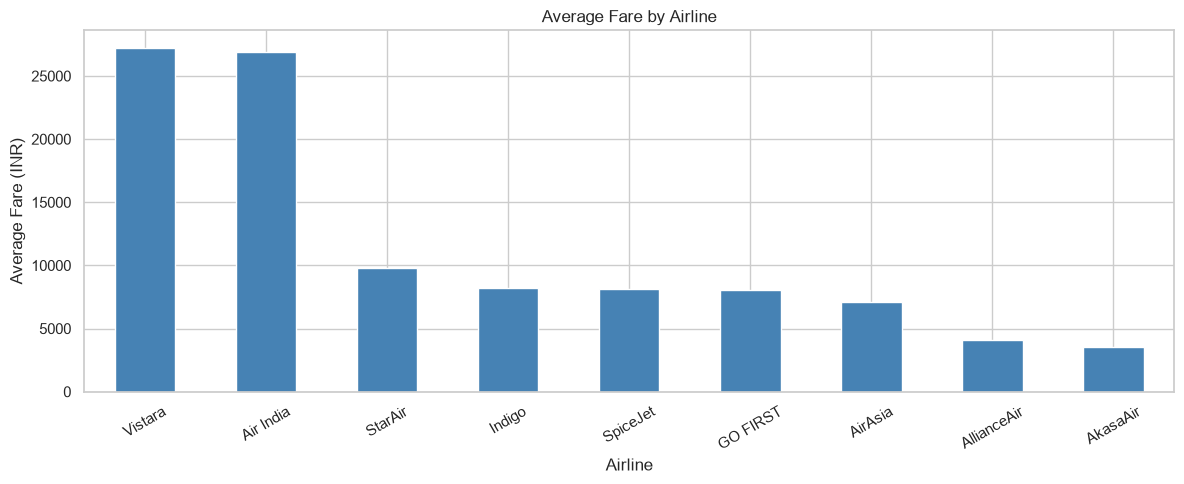

In [8]:
# Average fare by Airline
airline_fare = df.groupby('Airline')['Fare'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
airline_fare.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Average Fare by Airline')
ax.set_xlabel('Airline')
ax.set_ylabel('Average Fare (INR)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('plots/fare_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()

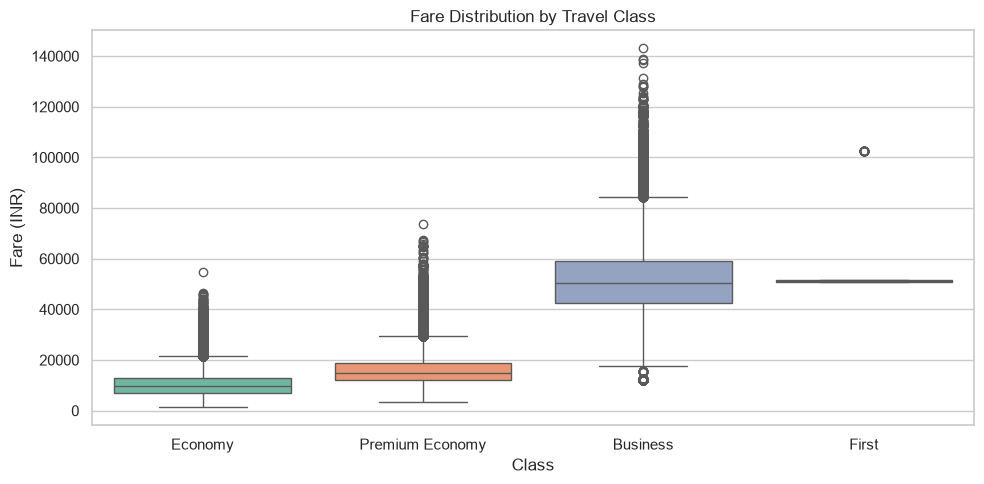

In [9]:
# Fare by Class
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Class', y='Fare', order=['Economy','Premium Economy','Business','First'],
            palette='Set2', ax=ax)
ax.set_title('Fare Distribution by Travel Class')
ax.set_ylabel('Fare (INR)')
plt.tight_layout()
plt.savefig('plots/fare_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

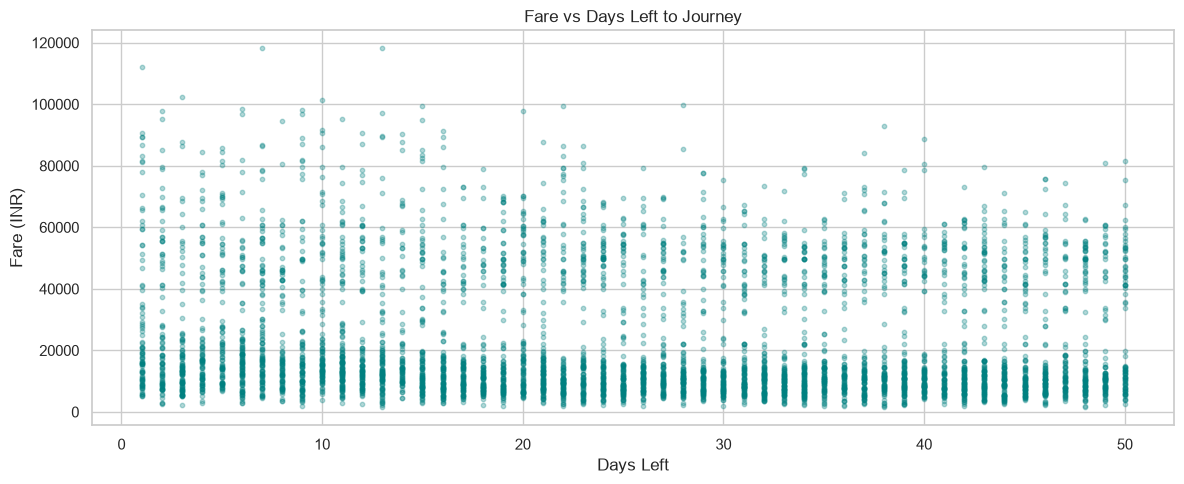

In [10]:
# Fare vs Days Left
sample = df.sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(sample['Days_left'], sample['Fare'], alpha=0.3, s=10, color='teal')
ax.set_title('Fare vs Days Left to Journey')
ax.set_xlabel('Days Left')
ax.set_ylabel('Fare (INR)')
plt.tight_layout()
plt.savefig('plots/fare_vs_daysleft.png', dpi=150, bbox_inches='tight')
plt.show()

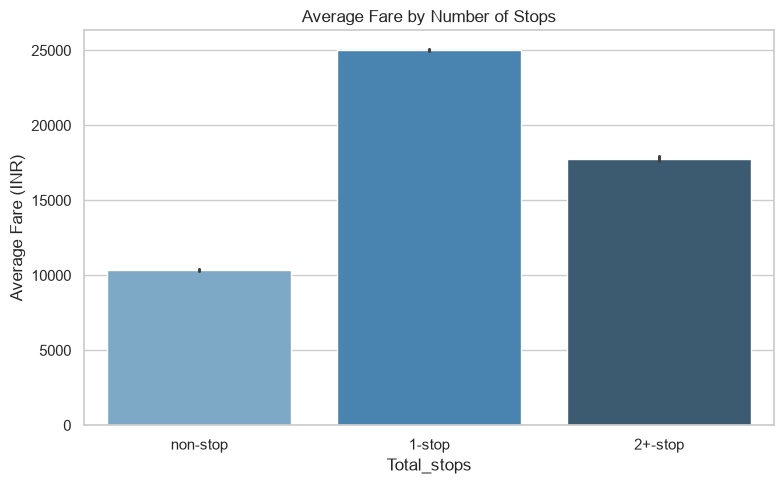

In [11]:
# Fare by number of stops
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df, x='Total_stops', y='Fare',
            order=['non-stop', '1-stop', '2+-stop'],
            palette='Blues_d', ax=ax)
ax.set_title('Average Fare by Number of Stops')
ax.set_ylabel('Average Fare (INR)')
plt.tight_layout()
plt.savefig('plots/fare_by_stops.png', dpi=150, bbox_inches='tight')
plt.show()

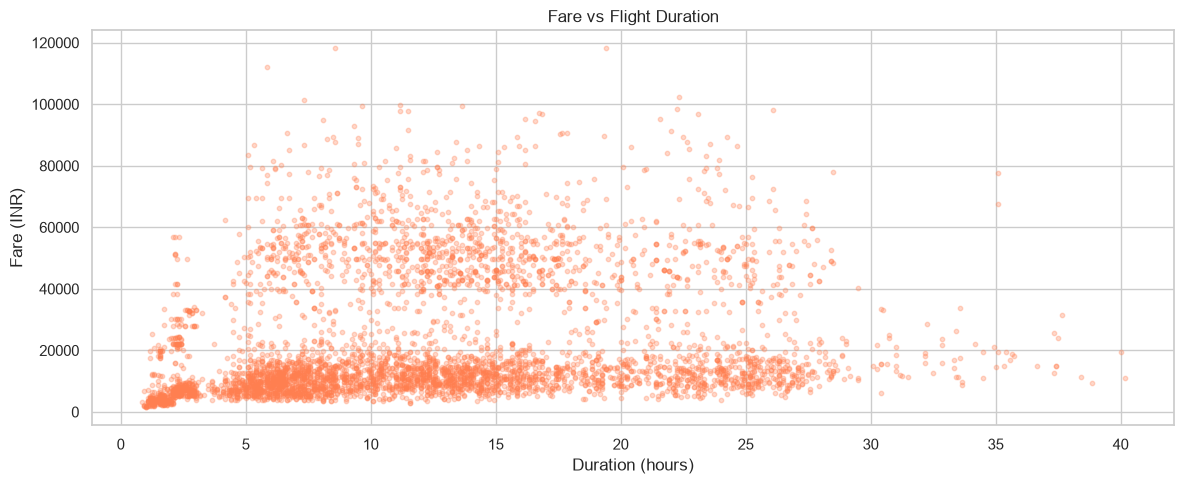

In [12]:
# Fare vs Duration
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(sample['Duration_in_hours'], sample['Fare'], alpha=0.3, s=10, color='coral')
ax.set_title('Fare vs Flight Duration')
ax.set_xlabel('Duration (hours)')
ax.set_ylabel('Fare (INR)')
plt.tight_layout()
plt.savefig('plots/fare_vs_duration.png', dpi=150, bbox_inches='tight')
plt.show()

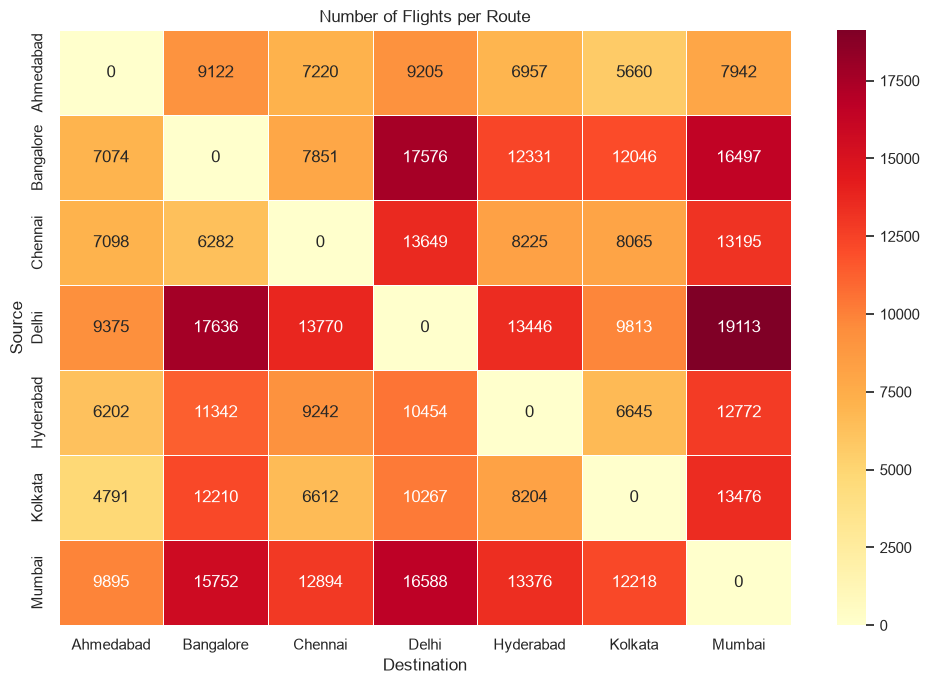

In [13]:
# Flights per Route (Source → Destination)
route_counts = df.groupby(['Source', 'Destination']).size().reset_index(name='Count')
pivot = route_counts.pivot(index='Source', columns='Destination', values='Count').fillna(0)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Number of Flights per Route')
plt.tight_layout()
plt.savefig('plots/route_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

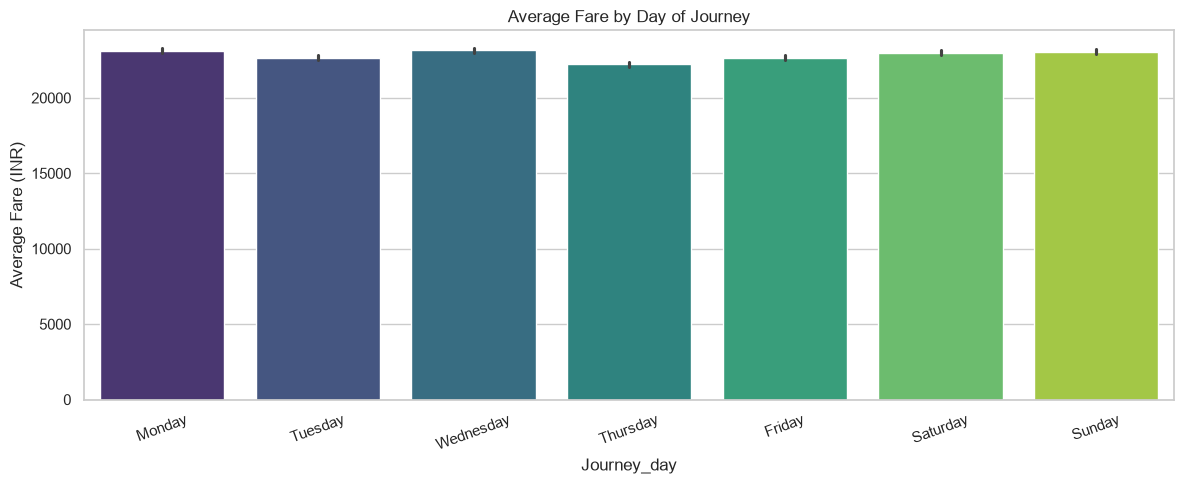

In [14]:
# Fare by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=df, x='Journey_day', y='Fare', order=day_order, palette='viridis', ax=ax)
ax.set_title('Average Fare by Day of Journey')
ax.set_ylabel('Average Fare (INR)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('plots/fare_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering & Preprocessing <a id='4'></a>

In [15]:
df_model = df.copy()

# Drop columns not useful for prediction
df_model.drop(columns=['Date_of_journey', 'Flight_code'], inplace=True)

# Encode Journey_day as ordinal (Mon=0 … Sun=6)
day_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,'Friday':4,'Saturday':5,'Sunday':6}
df_model['Journey_day'] = df_model['Journey_day'].map(day_map)

# Encode Total_stops as ordinal
stops_map = {'non-stop':0,'1-stop':1,'2+-stop':2}
df_model['Total_stops'] = df_model['Total_stops'].map(stops_map)

# Encode time-of-day features
time_map = {'Before 6 AM':0,'6 AM - 12 PM':1,'12 PM - 6 PM':2,'After 6 PM':3}
df_model['Departure'] = df_model['Departure'].map(time_map)
df_model['Arrival']   = df_model['Arrival'].map(time_map)

# Label-encode remaining categoricals
le = LabelEncoder()
cat_cols = ['Airline', 'Class', 'Source', 'Destination']
label_encoders = {}
for col in cat_cols:
    le_col = LabelEncoder()
    df_model[col] = le_col.fit_transform(df_model[col])
    label_encoders[col] = le_col

print('Preprocessed DataFrame:')
df_model.head()

Preprocessed DataFrame:


,Journey_day,Airline,Class,Source,Departure,Total_stops,Arrival,Destination,Duration_in_hours,Days_left,Fare
0,0,6,1,3,3,0,3,6,2.0833,1,5335
1,0,5,1,3,3,0,0,6,2.3333,1,5899
2,0,4,1,3,3,0,0,6,2.1667,1,5801
3,0,6,1,3,3,0,3,6,2.0833,1,5794
4,0,0,1,3,3,0,3,6,2.1667,1,5955


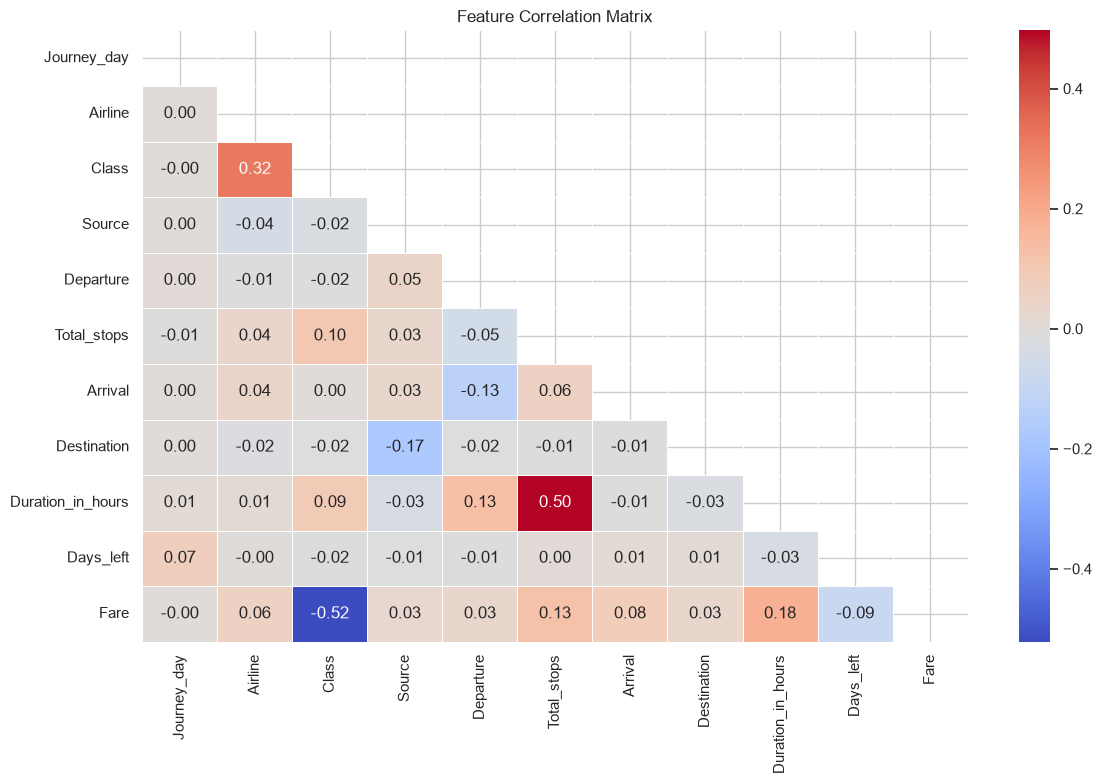

In [16]:
# Correlation heatmap of encoded features
fig, ax = plt.subplots(figsize=(12, 8))
corr = df_model.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            mask=np.triu(np.ones_like(corr, dtype=bool)), ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('plots/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
X = df_model.drop(columns=['Fare'])
y = df_model['Fare']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (361670, 10), Test size: (90418, 10)


## 5. Model Training <a id='5'></a>

In [18]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=15,
                                               n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                    learning_rate=0.1, random_state=42),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'MAE={mae:.0f}  RMSE={rmse:.0f}  R²={r2:.4f}')

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
results_df

Training Linear Regression... MAE=13252  RMSE=15698  R²=0.4028
Training Ridge Regression... MAE=13252  RMSE=15698  R²=0.4028
Training Decision Tree... MAE=3578  RMSE=6097  R²=0.9099
Training Random Forest... MAE=2702  RMSE=4893  R²=0.9420
Training Gradient Boosting... MAE=3414  RMSE=5702  R²=0.9212


,MAE,RMSE,R2
Random Forest,2702.343822,4893.238713,0.941978
Gradient Boosting,3414.144625,5701.954198,0.921214
Decision Tree,3577.989861,6096.631186,0.909930
Linear Regression,13252.344144,15698.361426,0.402815
Ridge Regression,13252.341543,15698.361532,0.402815


## 6. Model Evaluation <a id='6'></a>

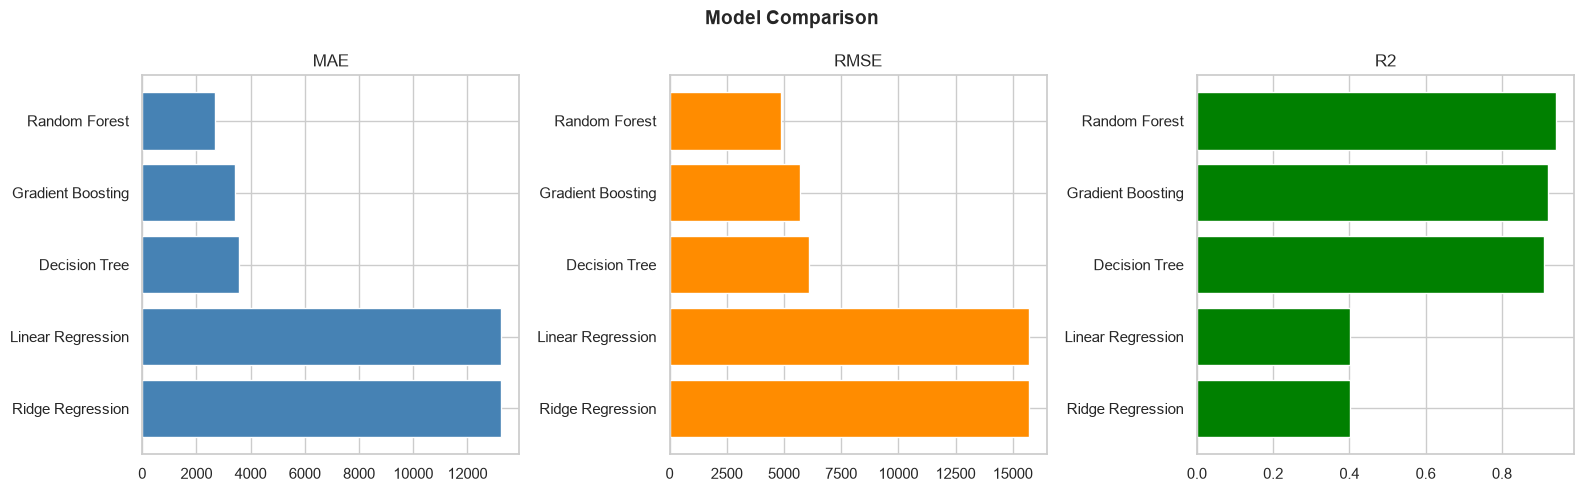

In [19]:
# Bar chart – R² comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R2']
colors  = ['steelblue', 'darkorange', 'green']
for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric]
    ax.barh(vals.index, vals.values, color=color, edgecolor='white')
    ax.set_title(metric)
    ax.invert_yaxis()
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

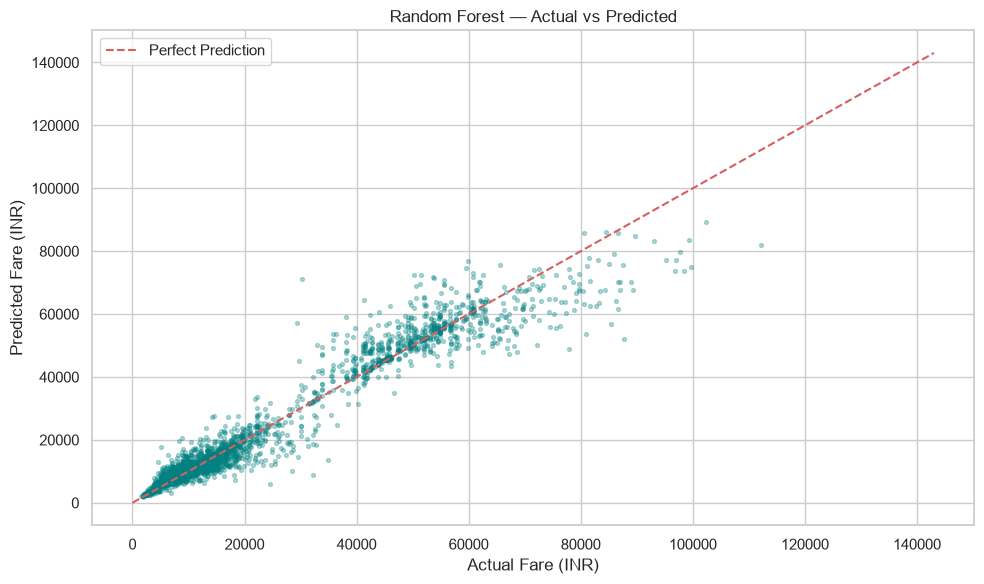

In [20]:
# Best model: Random Forest — Actual vs Predicted
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test[:3000], y_pred_best[:3000], alpha=0.3, s=8, color='teal')
lim = max(y_test.max(), y_pred_best.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual Fare (INR)')
ax.set_ylabel('Predicted Fare (INR)')
ax.set_title('Random Forest — Actual vs Predicted')
ax.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

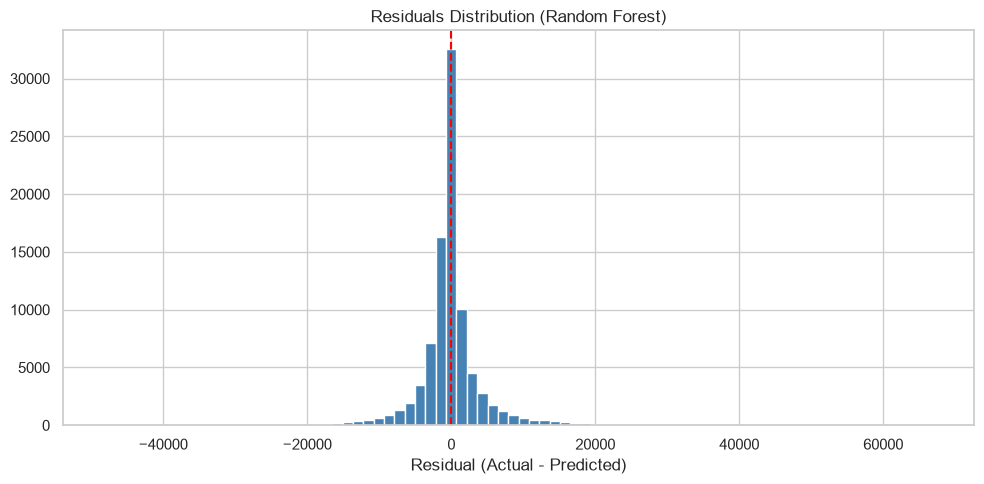

In [21]:
# Residuals distribution
residuals = y_test.values - y_pred_best
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals, bins=80, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_title('Residuals Distribution (Random Forest)')
ax.set_xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.savefig('plots/residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance <a id='7'></a>

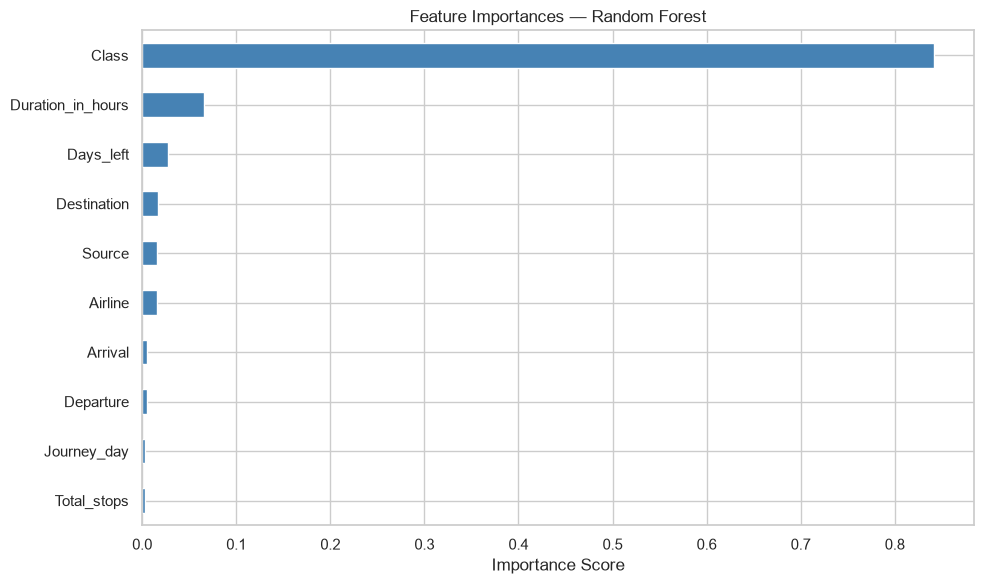

Class                0.842079
Duration_in_hours    0.065467
Days_left            0.027093
Destination          0.016279
Source               0.016178
Airline              0.015808
Arrival              0.005631
Departure            0.005439
Journey_day          0.003197
Total_stops          0.002830
dtype: float64


In [22]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(feat_imp.sort_values(ascending=False))

## 8. Save Model & Encoders <a id='8'></a>

In [23]:
os.makedirs('model', exist_ok=True)

joblib.dump(best_model,      'model/rf_model.pkl')
joblib.dump(label_encoders,  'model/label_encoders.pkl')
joblib.dump(list(X.columns), 'model/feature_columns.pkl')

print('Model and encoders saved to model/ ✓')
print(f'\n🏆 Best Model: Random Forest')
print(f"   R²   = {results['Random Forest']['R2']:.4f}")
print(f"   MAE  = ₹{results['Random Forest']['MAE']:,.0f}")
print(f"   RMSE = ₹{results['Random Forest']['RMSE']:,.0f}")

Model and encoders saved to model/ ✓

🏆 Best Model: Random Forest
   R²   = 0.9420
   MAE  = ₹2,702
   RMSE = ₹4,893
